# Step 10: Compare Baseline and Optimized Policies

This step compares the baseline nearest-center policy with the optimized capacity-constrained allocation policy.

In [1]:
# Step 10: Compare baseline and optimized logistics policies

from pathlib import Path
import pandas as pd
from IPython.display import display

# Set project directories
project_dir = Path("/Users/mac/Desktop/portfolio2_logistics_optimization")
data_processed_dir = project_dir / "data" / "processed"

# Load baseline and optimized metrics
baseline_metrics = pd.read_csv(data_processed_dir / "baseline_metrics.csv")
optimization_metrics = pd.read_csv(data_processed_dir / "optimization_metrics.csv")

print("=== Input Table Shapes ===")
print("baseline_metrics:", baseline_metrics.shape)
print("optimization_metrics:", optimization_metrics.shape)

# Select comparable columns
comparison_columns = [
    "policy",
    "total_demand",
    "total_capacity",
    "total_transportation_cost",
    "weighted_avg_distance_km",
    "num_fulfillment_centers",
    "num_customer_zones",
    "num_capacity_violated_centers",
    "total_excess_demand",
    "max_utilization_rate"
]

# Combine baseline and optimized metrics
policy_comparison = pd.concat(
    [
        baseline_metrics[comparison_columns],
        optimization_metrics[comparison_columns]
    ],
    ignore_index=True
)

print("\n=== Policy Comparison Metrics ===")
display(policy_comparison)

# Extract key values
baseline_cost = policy_comparison.loc[
    policy_comparison["policy"] == "baseline_nearest_center",
    "total_transportation_cost"
].iloc[0]

optimized_cost = policy_comparison.loc[
    policy_comparison["policy"] == "optimized_capacity_constrained_allocation",
    "total_transportation_cost"
].iloc[0]

baseline_distance = policy_comparison.loc[
    policy_comparison["policy"] == "baseline_nearest_center",
    "weighted_avg_distance_km"
].iloc[0]

optimized_distance = policy_comparison.loc[
    policy_comparison["policy"] == "optimized_capacity_constrained_allocation",
    "weighted_avg_distance_km"
].iloc[0]

baseline_excess = policy_comparison.loc[
    policy_comparison["policy"] == "baseline_nearest_center",
    "total_excess_demand"
].iloc[0]

optimized_excess = policy_comparison.loc[
    policy_comparison["policy"] == "optimized_capacity_constrained_allocation",
    "total_excess_demand"
].iloc[0]

baseline_violated_centers = policy_comparison.loc[
    policy_comparison["policy"] == "baseline_nearest_center",
    "num_capacity_violated_centers"
].iloc[0]

optimized_violated_centers = policy_comparison.loc[
    policy_comparison["policy"] == "optimized_capacity_constrained_allocation",
    "num_capacity_violated_centers"
].iloc[0]

# Calculate changes
cost_change_pct = (optimized_cost - baseline_cost) / baseline_cost * 100
distance_change_pct = (optimized_distance - baseline_distance) / baseline_distance * 100
excess_demand_reduction = baseline_excess - optimized_excess
excess_demand_reduction_pct = excess_demand_reduction / baseline_excess * 100

# Create summary table
policy_summary = pd.DataFrame(
    [
        {
            "comparison_item": "Transportation cost",
            "baseline_value": baseline_cost,
            "optimized_value": optimized_cost,
            "change": optimized_cost - baseline_cost,
            "change_percent": cost_change_pct
        },
        {
            "comparison_item": "Weighted average distance",
            "baseline_value": baseline_distance,
            "optimized_value": optimized_distance,
            "change": optimized_distance - baseline_distance,
            "change_percent": distance_change_pct
        },
        {
            "comparison_item": "Excess demand",
            "baseline_value": baseline_excess,
            "optimized_value": optimized_excess,
            "change": optimized_excess - baseline_excess,
            "change_percent": -excess_demand_reduction_pct
        },
        {
            "comparison_item": "Capacity violated centers",
            "baseline_value": baseline_violated_centers,
            "optimized_value": optimized_violated_centers,
            "change": optimized_violated_centers - baseline_violated_centers,
            "change_percent": None
        }
    ]
)

print("\n=== Policy Comparison Summary ===")
display(policy_summary)

# Print interpretation
print("\n=== Step 10 Interpretation ===")
print(f"Baseline total transportation cost: {baseline_cost:,.2f}")
print(f"Optimized total transportation cost: {optimized_cost:,.2f}")
print(f"Cost change vs baseline: {cost_change_pct:.2f}%")

print(f"\nBaseline weighted average distance: {baseline_distance:.2f} km")
print(f"Optimized weighted average distance: {optimized_distance:.2f} km")
print(f"Distance change vs baseline: {distance_change_pct:.2f}%")

print(f"\nBaseline total excess demand: {baseline_excess:,.0f}")
print(f"Optimized total excess demand: {optimized_excess:,.0f}")
print(f"Excess demand reduction: {excess_demand_reduction:,.0f}")
print(f"Excess demand reduction percent: {excess_demand_reduction_pct:.2f}%")

print(f"\nBaseline violated centers: {baseline_violated_centers}")
print(f"Optimized violated centers: {optimized_violated_centers}")

# Save comparison outputs
comparison_output_path = data_processed_dir / "policy_comparison_metrics.csv"
summary_output_path = data_processed_dir / "policy_comparison_summary.csv"

policy_comparison.to_csv(comparison_output_path, index=False)
policy_summary.to_csv(summary_output_path, index=False)

print("\n=== Step 10 Final Result ===")
print("Saved policy comparison metrics to:")
print(comparison_output_path)
print("Saved policy comparison summary to:")
print(summary_output_path)

=== Input Table Shapes ===
baseline_metrics: (1, 10)
optimization_metrics: (1, 15)

=== Policy Comparison Metrics ===


,policy,total_demand,total_capacity,total_transportation_cost,weighted_avg_distance_km,num_fulfillment_centers,num_customer_zones,num_capacity_violated_centers,total_excess_demand,max_utilization_rate
0,baseline_nearest_center,51291.0,56421,1.511536e+07,294.698175,12,30,4,26201.0,6.075954
1,optimized_capacity_constrained_allocation,51291.0,56421,1.770106e+07,345.110437,12,30,0,0.0,1.000000



=== Policy Comparison Summary ===


,comparison_item,baseline_value,optimized_value,change,change_percent
0,Transportation cost,1.511536e+07,1.770106e+07,2.585695e+06,17.106405
1,Weighted average distance,2.946982e+02,3.451104e+02,5.041226e+01,17.106405
2,Excess demand,2.620100e+04,0.000000e+00,-2.620100e+04,-100.000000
3,Capacity violated centers,4.000000e+00,0.000000e+00,-4.000000e+00,NaN



=== Step 10 Interpretation ===
Baseline total transportation cost: 15,115,364.07
Optimized total transportation cost: 17,701,059.42
Cost change vs baseline: 17.11%

Baseline weighted average distance: 294.70 km
Optimized weighted average distance: 345.11 km
Distance change vs baseline: 17.11%

Baseline total excess demand: 26,201
Optimized total excess demand: 0
Excess demand reduction: 26,201
Excess demand reduction percent: 100.00%

Baseline violated centers: 4
Optimized violated centers: 0

=== Step 10 Final Result ===
Saved policy comparison metrics to:
/Users/mac/Desktop/portfolio2_logistics_optimization/data/processed/policy_comparison_metrics.csv
Saved policy comparison summary to:
/Users/mac/Desktop/portfolio2_logistics_optimization/data/processed/policy_comparison_summary.csv


# Step 11: Visualize Policy Comparison Results

This step creates figures for comparing baseline and optimized logistics policies.

=== Input Table Shapes ===
policy_comparison: (2, 10)
optimized_center_load: (12, 9)

=== Policy Comparison Data for Plots ===


,policy,total_demand,total_capacity,total_transportation_cost,weighted_avg_distance_km,num_fulfillment_centers,num_customer_zones,num_capacity_violated_centers,total_excess_demand,max_utilization_rate,policy_label
0,baseline_nearest_center,51291.0,56421,1.511536e+07,294.698175,12,30,4,26201.0,6.075954,Baseline
1,optimized_capacity_constrained_allocation,51291.0,56421,1.770106e+07,345.110437,12,30,0,0.0,1.000000,Optimized


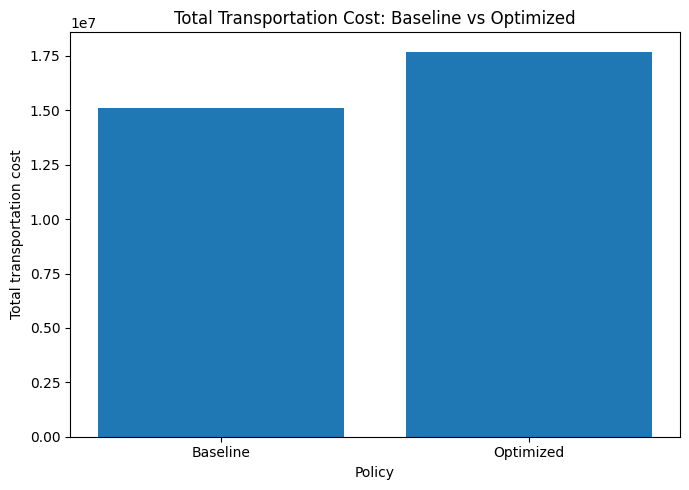

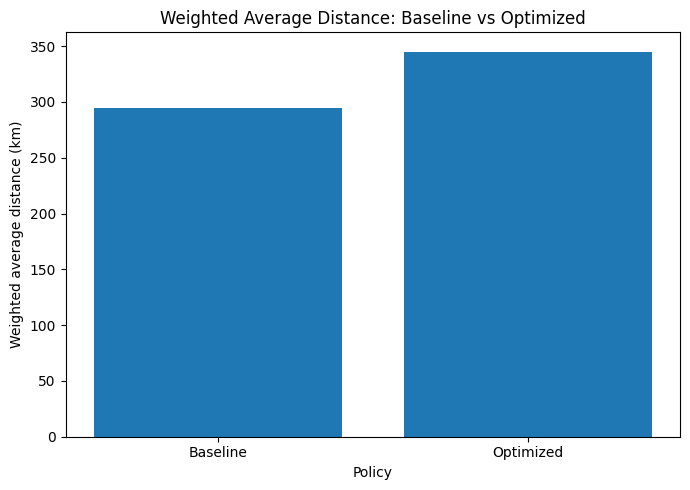

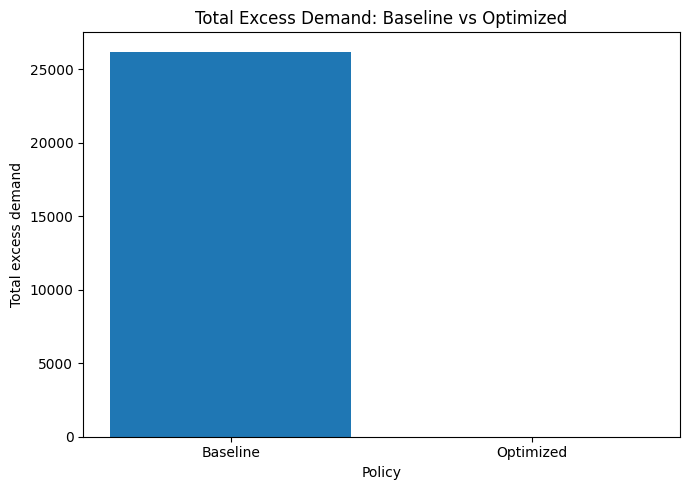

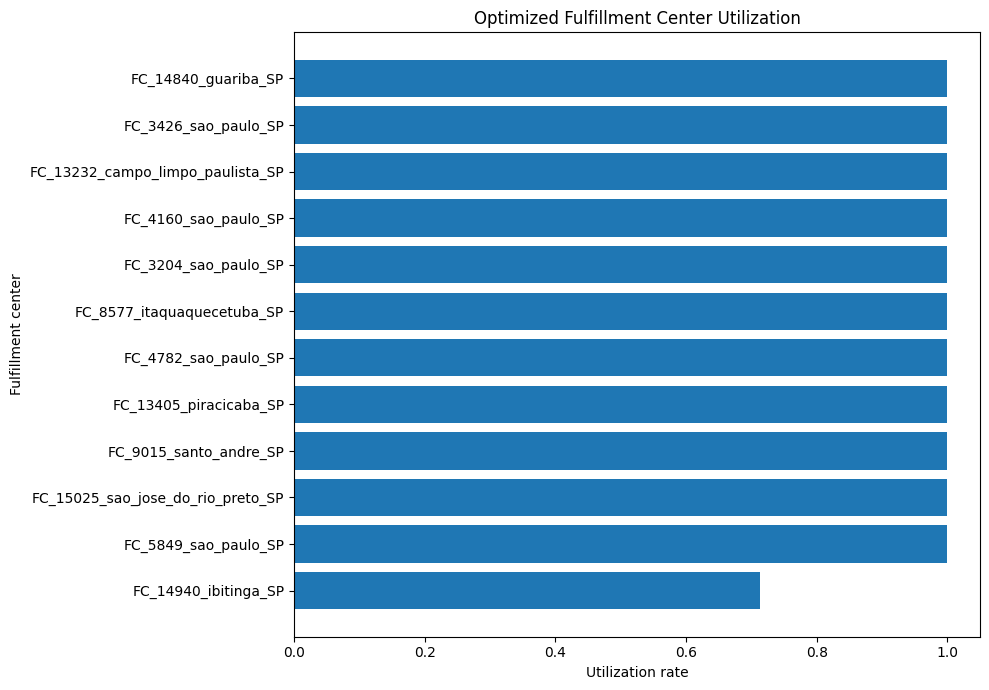


=== Step 11 Final Result ===
Saved PDF figures to:
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_01_total_transportation_cost.pdf
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_02_weighted_avg_distance.pdf
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_03_excess_demand.pdf
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_04_optimized_capacity_utilization.pdf

Saved PNG figures to:
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_01_total_transportation_cost.png
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_02_weighted_avg_distance.png
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_03_excess_demand.png
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_04_optimized_capacity_utilization.png


In [3]:
# Step 11: Visualize policy comparison results and save figures as PDF and PNG

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Set project directories
project_dir = Path("/Users/mac/Desktop/portfolio2_logistics_optimization")
data_processed_dir = project_dir / "data" / "processed"
figures_dir = project_dir / "outputs" / "figures"

# Create figures directory if it does not exist
figures_dir.mkdir(parents=True, exist_ok=True)

# Load comparison metrics and optimized center load
policy_comparison = pd.read_csv(data_processed_dir / "policy_comparison_metrics.csv")
optimized_center_load = pd.read_csv(data_processed_dir / "optimized_center_load.csv")

print("=== Input Table Shapes ===")
print("policy_comparison:", policy_comparison.shape)
print("optimized_center_load:", optimized_center_load.shape)

# Create shorter policy labels for plotting
policy_label_map = {
    "baseline_nearest_center": "Baseline",
    "optimized_capacity_constrained_allocation": "Optimized"
}

policy_comparison["policy_label"] = policy_comparison["policy"].map(policy_label_map)

print("\n=== Policy Comparison Data for Plots ===")
display(policy_comparison)

# -----------------------------
# Figure 1: Total transportation cost comparison
# -----------------------------

plt.figure(figsize=(7, 5))
plt.bar(
    policy_comparison["policy_label"],
    policy_comparison["total_transportation_cost"]
)
plt.title("Total Transportation Cost: Baseline vs Optimized")
plt.xlabel("Policy")
plt.ylabel("Total transportation cost")
plt.tight_layout()

fig1_pdf_path = figures_dir / "fig_01_total_transportation_cost.pdf"
fig1_png_path = figures_dir / "fig_01_total_transportation_cost.png"

plt.savefig(fig1_pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(fig1_png_path, format="png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 2: Weighted average distance comparison
# -----------------------------

plt.figure(figsize=(7, 5))
plt.bar(
    policy_comparison["policy_label"],
    policy_comparison["weighted_avg_distance_km"]
)
plt.title("Weighted Average Distance: Baseline vs Optimized")
plt.xlabel("Policy")
plt.ylabel("Weighted average distance (km)")
plt.tight_layout()

fig2_pdf_path = figures_dir / "fig_02_weighted_avg_distance.pdf"
fig2_png_path = figures_dir / "fig_02_weighted_avg_distance.png"

plt.savefig(fig2_pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(fig2_png_path, format="png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 3: Total excess demand comparison
# -----------------------------

plt.figure(figsize=(7, 5))
plt.bar(
    policy_comparison["policy_label"],
    policy_comparison["total_excess_demand"]
)
plt.title("Total Excess Demand: Baseline vs Optimized")
plt.xlabel("Policy")
plt.ylabel("Total excess demand")
plt.tight_layout()

fig3_pdf_path = figures_dir / "fig_03_excess_demand.pdf"
fig3_png_path = figures_dir / "fig_03_excess_demand.png"

plt.savefig(fig3_pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(fig3_png_path, format="png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 4: Optimized fulfillment center utilization
# -----------------------------

optimized_center_load_plot = optimized_center_load.copy()
optimized_center_load_plot = optimized_center_load_plot.sort_values(
    "utilization_rate",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    optimized_center_load_plot["seller_center_id"],
    optimized_center_load_plot["utilization_rate"]
)
plt.title("Optimized Fulfillment Center Utilization")
plt.xlabel("Utilization rate")
plt.ylabel("Fulfillment center")
plt.tight_layout()

fig4_pdf_path = figures_dir / "fig_04_optimized_capacity_utilization.pdf"
fig4_png_path = figures_dir / "fig_04_optimized_capacity_utilization.png"

plt.savefig(fig4_pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(fig4_png_path, format="png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Final output paths
# -----------------------------

print("\n=== Step 11 Final Result ===")
print("Saved PDF figures to:")
print(fig1_pdf_path)
print(fig2_pdf_path)
print(fig3_pdf_path)
print(fig4_pdf_path)

print("\nSaved PNG figures to:")
print(fig1_png_path)
print(fig2_png_path)
print(fig3_png_path)
print(fig4_png_path)

# Step 12: Export Final Result Tables

This step creates clean result tables for the final report.

In [4]:
# Step 12: Export final result tables for the report

from pathlib import Path
import pandas as pd
from IPython.display import display

# Set project directories
project_dir = Path("/Users/mac/Desktop/portfolio2_logistics_optimization")
data_processed_dir = project_dir / "data" / "processed"
tables_dir = project_dir / "outputs" / "tables"

# Create tables directory if it does not exist
tables_dir.mkdir(parents=True, exist_ok=True)

# Load processed outputs
policy_comparison = pd.read_csv(data_processed_dir / "policy_comparison_metrics.csv")
optimized_center_load = pd.read_csv(data_processed_dir / "optimized_center_load.csv")
optimized_allocation = pd.read_csv(data_processed_dir / "optimized_allocation.csv")

print("=== Input Table Shapes ===")
print("policy_comparison:", policy_comparison.shape)
print("optimized_center_load:", optimized_center_load.shape)
print("optimized_allocation:", optimized_allocation.shape)

# -----------------------------
# Table 1: Policy comparison
# -----------------------------

table_01_policy_comparison = policy_comparison.copy()

# Create readable policy names
policy_name_map = {
    "baseline_nearest_center": "Baseline nearest-center policy",
    "optimized_capacity_constrained_allocation": "Optimized capacity-constrained allocation"
}

table_01_policy_comparison["policy"] = table_01_policy_comparison["policy"].map(policy_name_map)

# Select and rename columns
table_01_policy_comparison = table_01_policy_comparison[
    [
        "policy",
        "total_demand",
        "total_capacity",
        "total_transportation_cost",
        "weighted_avg_distance_km",
        "num_capacity_violated_centers",
        "total_excess_demand",
        "max_utilization_rate"
    ]
]

table_01_policy_comparison = table_01_policy_comparison.rename(
    columns={
        "policy": "Policy",
        "total_demand": "Total Demand",
        "total_capacity": "Total Capacity",
        "total_transportation_cost": "Total Transportation Cost",
        "weighted_avg_distance_km": "Weighted Avg Distance (km)",
        "num_capacity_violated_centers": "Capacity Violated Centers",
        "total_excess_demand": "Total Excess Demand",
        "max_utilization_rate": "Max Utilization Rate"
    }
)

print("\n=== Table 1: Policy Comparison ===")
display(table_01_policy_comparison)

# -----------------------------
# Table 2: Optimized center utilization
# -----------------------------

table_02_center_utilization = optimized_center_load.copy()

table_02_center_utilization = table_02_center_utilization[
    [
        "seller_center_id",
        "seller_city",
        "seller_state",
        "assigned_demand",
        "warehouse_capacity",
        "utilization_rate",
        "capacity_violation",
        "excess_demand",
        "assigned_zones"
    ]
]

table_02_center_utilization = table_02_center_utilization.sort_values(
    "utilization_rate",
    ascending=False
)

table_02_center_utilization = table_02_center_utilization.rename(
    columns={
        "seller_center_id": "Fulfillment Center",
        "seller_city": "City",
        "seller_state": "State",
        "assigned_demand": "Assigned Demand",
        "warehouse_capacity": "Capacity",
        "utilization_rate": "Utilization Rate",
        "capacity_violation": "Capacity Violation",
        "excess_demand": "Excess Demand",
        "assigned_zones": "Assigned Customer Zones"
    }
)

print("\n=== Table 2: Optimized Fulfillment Center Utilization ===")
display(table_02_center_utilization)

# -----------------------------
# Table 3: Top optimized allocation lanes
# -----------------------------

table_03_top_lanes = optimized_allocation.copy()

table_03_top_lanes = table_03_top_lanes[
    [
        "customer_zone_id",
        "customer_city",
        "customer_state",
        "seller_center_id",
        "seller_city",
        "seller_state",
        "allocated_demand",
        "distance_km",
        "optimized_transportation_cost"
    ]
]

table_03_top_lanes = table_03_top_lanes.sort_values(
    "allocated_demand",
    ascending=False
).head(15)

table_03_top_lanes = table_03_top_lanes.rename(
    columns={
        "customer_zone_id": "Customer Zone",
        "customer_city": "Customer City",
        "customer_state": "Customer State",
        "seller_center_id": "Fulfillment Center",
        "seller_city": "Center City",
        "seller_state": "Center State",
        "allocated_demand": "Allocated Demand",
        "distance_km": "Distance (km)",
        "optimized_transportation_cost": "Optimized Transportation Cost"
    }
)

print("\n=== Table 3: Top Optimized Allocation Lanes ===")
display(table_03_top_lanes)

# Save tables
table_01_path = tables_dir / "table_01_policy_comparison.csv"
table_02_path = tables_dir / "table_02_optimized_center_utilization.csv"
table_03_path = tables_dir / "table_03_top_optimized_allocation_lanes.csv"

table_01_policy_comparison.to_csv(table_01_path, index=False)
table_02_center_utilization.to_csv(table_02_path, index=False)
table_03_top_lanes.to_csv(table_03_path, index=False)

print("\n=== Step 12 Final Result ===")
print("Saved final result tables to:")
print(table_01_path)
print(table_02_path)
print(table_03_path)

=== Input Table Shapes ===
policy_comparison: (2, 10)
optimized_center_load: (12, 9)
optimized_allocation: (41, 24)

=== Table 1: Policy Comparison ===


,Policy,Total Demand,Total Capacity,Total Transportation Cost,Weighted Avg Distance (km),Capacity Violated Centers,Total Excess Demand,Max Utilization Rate
0,Baseline nearest-center policy,51291.0,56421,1.511536e+07,294.698175,4,26201.0,6.075954
1,Optimized capacity-constrained allocation,51291.0,56421,1.770106e+07,345.110437,0,0.0,1.000000



=== Table 2: Optimized Fulfillment Center Utilization ===


,Fulfillment Center,City,State,Assigned Demand,Capacity,Utilization Rate,Capacity Violation,Excess Demand,Assigned Customer Zones
1,FC_5849_sao_paulo_SP,sao paulo,SP,4732.0,4732,1.000000,False,0.0,2
2,FC_15025_sao_jose_do_rio_preto_SP,sao jose do rio preto,SP,4717.0,4717,1.000000,False,0.0,5
3,FC_9015_santo_andre_SP,santo andre,SP,4037.0,4037,1.000000,False,0.0,4
4,FC_13405_piracicaba_SP,piracicaba,SP,3688.0,3688,1.000000,False,0.0,5
8,FC_4160_sao_paulo_SP,sao paulo,SP,2857.0,2857,1.000000,False,0.0,1
5,FC_4782_sao_paulo_SP,sao paulo,SP,3506.0,3506,1.000000,False,0.0,1
6,FC_8577_itaquaquecetuba_SP,itaquaquecetuba,SP,3402.0,3402,1.000000,False,0.0,2
7,FC_3204_sao_paulo_SP,sao paulo,SP,3341.0,3341,1.000000,False,0.0,1
10,FC_3426_sao_paulo_SP,sao paulo,SP,2720.0,2720,1.000000,False,0.0,2
9,FC_13232_campo_limpo_paulista_SP,campo limpo paulista,SP,2779.0,2779,1.000000,False,0.0,3



=== Table 3: Top Optimized Allocation Lanes ===


,Customer Zone,Customer City,Customer State,Fulfillment Center,Center City,Center State,Allocated Demand,Distance (km),Optimized Transportation Cost
37,sao_paulo_SP,sao paulo,SP,FC_5849_sao_paulo_SP,sao paulo,SP,3902.0,15.300012,5.970065e+04
36,sao_paulo_SP,sao paulo,SP,FC_4782_sao_paulo_SP,sao paulo,SP,3506.0,15.031276,5.269965e+04
33,sao_paulo_SP,sao paulo,SP,FC_3204_sao_paulo_SP,sao paulo,SP,3341.0,7.996017,2.671469e+04
25,rio_de_janeiro_RJ,rio de janeiro,RJ,FC_14940_ibitinga_SP,ibitinga,SP,3313.0,581.153715,1.925362e+06
26,rio_de_janeiro_RJ,rio de janeiro,RJ,FC_8577_itaquaquecetuba_SP,itaquaquecetuba,SP,2967.0,317.463138,9.419131e+05
35,sao_paulo_SP,sao paulo,SP,FC_4160_sao_paulo_SP,sao paulo,SP,2857.0,6.352208,1.814826e+04
3,belo_horizonte_MG,belo horizonte,MG,FC_14940_ibitinga_SP,ibitinga,SP,2806.0,546.489156,1.533449e+06
34,sao_paulo_SP,sao paulo,SP,FC_3426_sao_paulo_SP,sao paulo,SP,2433.0,10.125814,2.463611e+04
4,brasilia_DF,brasilia,DF,FC_15025_sao_jose_do_rio_preto_SP,sao jose do rio preto,SP,2157.0,575.369162,1.241071e+06
7,curitiba_PR,curitiba,PR,FC_14940_ibitinga_SP,ibitinga,SP,1723.0,413.307191,7.121283e+05



=== Step 12 Final Result ===
Saved final result tables to:
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/tables/table_01_policy_comparison.csv
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/tables/table_02_optimized_center_utilization.csv
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/tables/table_03_top_optimized_allocation_lanes.csv


# Step 13: Capacity Sensitivity Analysis

This step tests how different fulfillment center capacity buffers affect transportation cost, distance, and utilization.

In [5]:
# Step 13: Capacity sensitivity analysis

from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

# PuLP should already be installed from Step 9B
import pulp

# Set project directories
project_dir = Path("/Users/mac/Desktop/portfolio2_logistics_optimization")
data_processed_dir = project_dir / "data" / "processed"
tables_dir = project_dir / "outputs" / "tables"

# Create tables directory if it does not exist
tables_dir.mkdir(parents=True, exist_ok=True)

# Load input data
distance_cost_matrix = pd.read_csv(data_processed_dir / "distance_cost_matrix.csv")
seller_centers_original = pd.read_csv(data_processed_dir / "seller_fulfillment_centers_with_capacity.csv")
baseline_metrics = pd.read_csv(data_processed_dir / "baseline_metrics.csv")

print("=== Input Table Shapes ===")
print("distance_cost_matrix:", distance_cost_matrix.shape)
print("seller_centers_original:", seller_centers_original.shape)
print("baseline_metrics:", baseline_metrics.shape)

# Define customer zones and fulfillment centers
customer_zones = sorted(distance_cost_matrix["customer_zone_id"].unique())
fulfillment_centers = sorted(distance_cost_matrix["seller_center_id"].unique())

# Create lookup dictionaries
demand_dict = (
    distance_cost_matrix
    .drop_duplicates("customer_zone_id")
    .set_index("customer_zone_id")["demand"]
    .to_dict()
)

distance_dict = (
    distance_cost_matrix
    .set_index(["customer_zone_id", "seller_center_id"])["distance_km"]
    .to_dict()
)

historical_orders_dict = (
    seller_centers_original
    .set_index("seller_center_id")["historical_orders"]
    .to_dict()
)

total_demand = sum(demand_dict.values())
total_historical_orders = sum(historical_orders_dict.values())

print("\n=== Base Demand and Seller Volume ===")
print("Total selected demand:", total_demand)
print("Total historical seller orders:", total_historical_orders)

# Capacity buffers to test
capacity_buffers = [1.00, 1.05, 1.10, 1.20, 1.30]

sensitivity_results = []

for capacity_buffer in capacity_buffers:
    
    # Construct capacity for this buffer
    target_total_capacity = int(np.ceil(total_demand * capacity_buffer))
    
    seller_capacity = {}
    for f in fulfillment_centers:
        seller_capacity[f] = int(
            round(
                historical_orders_dict[f] / total_historical_orders * target_total_capacity
            )
        )
    
    # Adjust rounding difference
    capacity_gap = target_total_capacity - sum(seller_capacity.values())
    
    if capacity_gap != 0:
        largest_center = max(seller_capacity, key=seller_capacity.get)
        seller_capacity[largest_center] += capacity_gap
    
    # Create optimization model
    model = pulp.LpProblem(
        f"capacity_sensitivity_buffer_{capacity_buffer}",
        pulp.LpMinimize
    )
    
    # Decision variable:
    # y[c, f] = number of orders from customer zone c served by fulfillment center f
    y = pulp.LpVariable.dicts(
        "shipment",
        ((c, f) for c in customer_zones for f in fulfillment_centers),
        lowBound=0,
        cat="Continuous"
    )
    
    # Objective function: minimize total distance-weighted cost
    model += pulp.lpSum(
        distance_dict[(c, f)] * y[(c, f)]
        for c in customer_zones
        for f in fulfillment_centers
    )
    
    # Constraint 1: all customer zone demand must be served
    for c in customer_zones:
        model += pulp.lpSum(
            y[(c, f)] for f in fulfillment_centers
        ) == demand_dict[c], f"demand_fulfillment_{c}"
    
    # Constraint 2: fulfillment center capacity cannot be exceeded
    for f in fulfillment_centers:
        model += pulp.lpSum(
            y[(c, f)] for c in customer_zones
        ) <= seller_capacity[f], f"capacity_{f}"
    
    # Solve model
    solver = pulp.PULP_CBC_CMD(msg=False)
    model.solve(solver)
    
    solver_status = pulp.LpStatus[model.status]
    
    if solver_status == "Optimal":
        
        total_transportation_cost = pulp.value(model.objective)
        weighted_avg_distance_km = total_transportation_cost / total_demand
        
        center_loads = []
        
        for f in fulfillment_centers:
            assigned_demand = sum(
                pulp.value(y[(c, f)]) for c in customer_zones
            )
            
            center_loads.append(
                {
                    "seller_center_id": f,
                    "assigned_demand": assigned_demand,
                    "warehouse_capacity": seller_capacity[f],
                    "utilization_rate": assigned_demand / seller_capacity[f]
                }
            )
        
        center_loads_df = pd.DataFrame(center_loads)
        
        max_utilization_rate = center_loads_df["utilization_rate"].max()
        avg_utilization_rate = center_loads_df["utilization_rate"].mean()
        num_capacity_violated_centers = (
            center_loads_df["assigned_demand"]
            > center_loads_df["warehouse_capacity"] + 1e-6
        ).sum()
        
        total_excess_demand = (
            center_loads_df["assigned_demand"]
            - center_loads_df["warehouse_capacity"]
        ).clip(lower=0).sum()
        
    else:
        total_transportation_cost = None
        weighted_avg_distance_km = None
        max_utilization_rate = None
        avg_utilization_rate = None
        num_capacity_violated_centers = None
        total_excess_demand = None
    
    sensitivity_results.append(
        {
            "capacity_buffer": capacity_buffer,
            "solver_status": solver_status,
            "total_demand": total_demand,
            "target_total_capacity": target_total_capacity,
            "actual_total_capacity": sum(seller_capacity.values()),
            "total_transportation_cost": total_transportation_cost,
            "weighted_avg_distance_km": weighted_avg_distance_km,
            "max_utilization_rate": max_utilization_rate,
            "avg_utilization_rate": avg_utilization_rate,
            "num_capacity_violated_centers": num_capacity_violated_centers,
            "total_excess_demand": total_excess_demand
        }
    )

# Convert results to DataFrame
sensitivity_results_df = pd.DataFrame(sensitivity_results)

print("\n=== Capacity Sensitivity Results ===")
display(sensitivity_results_df)

# Create report-ready table
table_04_capacity_sensitivity = sensitivity_results_df.copy()

table_04_capacity_sensitivity = table_04_capacity_sensitivity.rename(
    columns={
        "capacity_buffer": "Capacity Buffer",
        "solver_status": "Solver Status",
        "total_demand": "Total Demand",
        "target_total_capacity": "Target Total Capacity",
        "actual_total_capacity": "Actual Total Capacity",
        "total_transportation_cost": "Total Transportation Cost",
        "weighted_avg_distance_km": "Weighted Avg Distance (km)",
        "max_utilization_rate": "Max Utilization Rate",
        "avg_utilization_rate": "Avg Utilization Rate",
        "num_capacity_violated_centers": "Capacity Violated Centers",
        "total_excess_demand": "Total Excess Demand"
    }
)

print("\n=== Table 4: Capacity Sensitivity Analysis ===")
display(table_04_capacity_sensitivity)

# Save outputs
sensitivity_output_path = data_processed_dir / "capacity_sensitivity_results.csv"
table_04_path = tables_dir / "table_04_capacity_sensitivity.csv"

sensitivity_results_df.to_csv(sensitivity_output_path, index=False)
table_04_capacity_sensitivity.to_csv(table_04_path, index=False)

print("\n=== Step 13 Final Result ===")
print("Saved capacity sensitivity results to:")
print(sensitivity_output_path)
print("Saved report-ready capacity sensitivity table to:")
print(table_04_path)

=== Input Table Shapes ===
distance_cost_matrix: (360, 22)
seller_centers_original: (12, 11)
baseline_metrics: (1, 10)

=== Base Demand and Seller Volume ===
Total selected demand: 51291
Total historical seller orders: 23896

=== Capacity Sensitivity Results ===


,capacity_buffer,solver_status,total_demand,target_total_capacity,actual_total_capacity,total_transportation_cost,weighted_avg_distance_km,max_utilization_rate,avg_utilization_rate,num_capacity_violated_centers,total_excess_demand
0,1.00,Optimal,51291,51291,51291,1.841534e+07,359.036398,1.0,1.000000,0,0.0
1,1.05,Optimal,51291,53856,53856,1.805106e+07,351.934271,1.0,0.987512,0,0.0
2,1.10,Optimal,51291,56421,56421,1.770106e+07,345.110437,1.0,0.976163,0,0.0
3,1.20,Optimal,51291,61550,61550,1.701093e+07,331.655255,1.0,0.956297,0,0.0
4,1.30,Optimal,51291,66679,66679,1.634544e+07,318.680434,1.0,0.939490,0,0.0



=== Table 4: Capacity Sensitivity Analysis ===


,Capacity Buffer,Solver Status,Total Demand,Target Total Capacity,Actual Total Capacity,Total Transportation Cost,Weighted Avg Distance (km),Max Utilization Rate,Avg Utilization Rate,Capacity Violated Centers,Total Excess Demand
0,1.00,Optimal,51291,51291,51291,1.841534e+07,359.036398,1.0,1.000000,0,0.0
1,1.05,Optimal,51291,53856,53856,1.805106e+07,351.934271,1.0,0.987512,0,0.0
2,1.10,Optimal,51291,56421,56421,1.770106e+07,345.110437,1.0,0.976163,0,0.0
3,1.20,Optimal,51291,61550,61550,1.701093e+07,331.655255,1.0,0.956297,0,0.0
4,1.30,Optimal,51291,66679,66679,1.634544e+07,318.680434,1.0,0.939490,0,0.0



=== Step 13 Final Result ===
Saved capacity sensitivity results to:
/Users/mac/Desktop/portfolio2_logistics_optimization/data/processed/capacity_sensitivity_results.csv
Saved report-ready capacity sensitivity table to:
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/tables/table_04_capacity_sensitivity.csv


# Step 14: Visualize Capacity Sensitivity Analysis

This step creates figures to show how transportation cost, average distance, and utilization change under different capacity buffers.

=== Input Table Shape ===
sensitivity_results: (5, 11)

=== Capacity Sensitivity Data for Plots ===


,capacity_buffer,solver_status,total_demand,target_total_capacity,actual_total_capacity,total_transportation_cost,weighted_avg_distance_km,max_utilization_rate,avg_utilization_rate,num_capacity_violated_centers,total_excess_demand
0,1.00,Optimal,51291,51291,51291,1.841534e+07,359.036398,1.0,1.000000,0,0.0
1,1.05,Optimal,51291,53856,53856,1.805106e+07,351.934271,1.0,0.987512,0,0.0
2,1.10,Optimal,51291,56421,56421,1.770106e+07,345.110437,1.0,0.976163,0,0.0
3,1.20,Optimal,51291,61550,61550,1.701093e+07,331.655255,1.0,0.956297,0,0.0
4,1.30,Optimal,51291,66679,66679,1.634544e+07,318.680434,1.0,0.939490,0,0.0


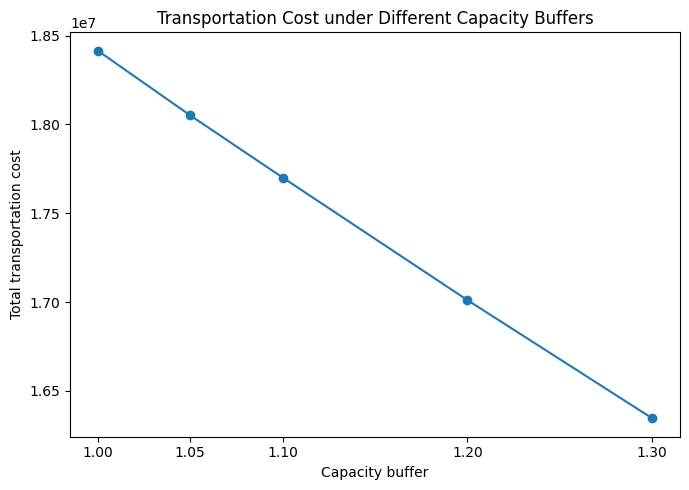

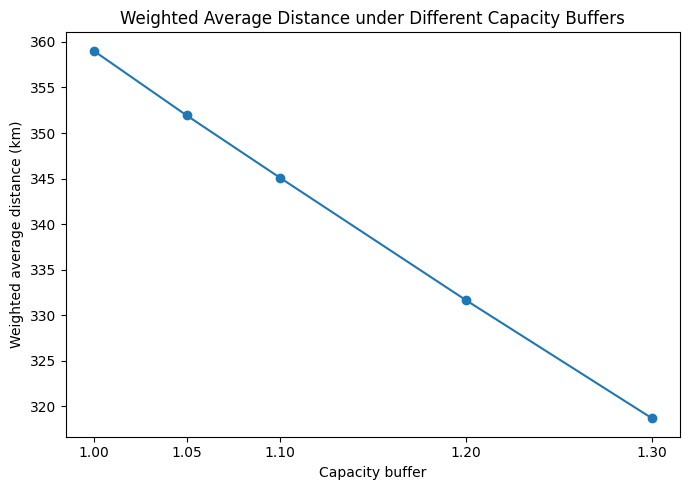

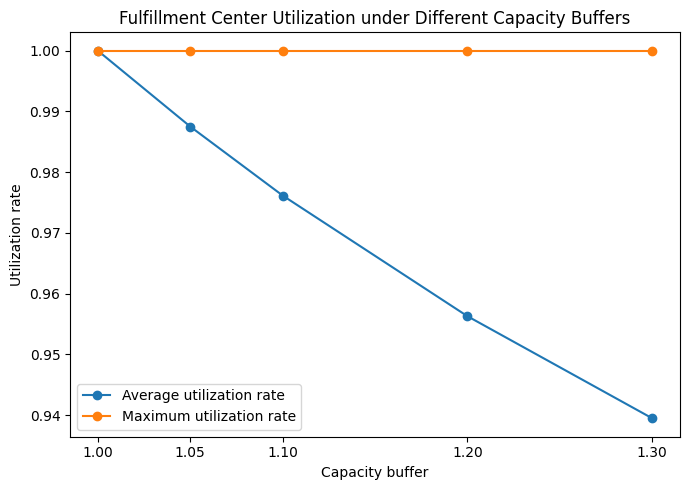


=== Step 14 Final Result ===
Saved PDF figures to:
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_05_capacity_buffer_cost.pdf
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_06_capacity_buffer_distance.pdf
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_07_capacity_buffer_utilization.pdf

Saved PNG figures to:
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_05_capacity_buffer_cost.png
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_06_capacity_buffer_distance.png
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/figures/fig_07_capacity_buffer_utilization.png


In [6]:
# Step 14: Visualize capacity sensitivity analysis and save figures as PDF and PNG

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Set project directories
project_dir = Path("/Users/mac/Desktop/portfolio2_logistics_optimization")
data_processed_dir = project_dir / "data" / "processed"
figures_dir = project_dir / "outputs" / "figures"

# Create figures directory if it does not exist
figures_dir.mkdir(parents=True, exist_ok=True)

# Load capacity sensitivity results
sensitivity_results = pd.read_csv(data_processed_dir / "capacity_sensitivity_results.csv")

print("=== Input Table Shape ===")
print("sensitivity_results:", sensitivity_results.shape)

print("\n=== Capacity Sensitivity Data for Plots ===")
display(sensitivity_results)

# -----------------------------
# Figure 5: Capacity buffer vs total transportation cost
# -----------------------------

plt.figure(figsize=(7, 5))
plt.plot(
    sensitivity_results["capacity_buffer"],
    sensitivity_results["total_transportation_cost"],
    marker="o"
)
plt.title("Transportation Cost under Different Capacity Buffers")
plt.xlabel("Capacity buffer")
plt.ylabel("Total transportation cost")
plt.xticks(sensitivity_results["capacity_buffer"])
plt.tight_layout()

fig5_pdf_path = figures_dir / "fig_05_capacity_buffer_cost.pdf"
fig5_png_path = figures_dir / "fig_05_capacity_buffer_cost.png"

plt.savefig(fig5_pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(fig5_png_path, format="png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 6: Capacity buffer vs weighted average distance
# -----------------------------

plt.figure(figsize=(7, 5))
plt.plot(
    sensitivity_results["capacity_buffer"],
    sensitivity_results["weighted_avg_distance_km"],
    marker="o"
)
plt.title("Weighted Average Distance under Different Capacity Buffers")
plt.xlabel("Capacity buffer")
plt.ylabel("Weighted average distance (km)")
plt.xticks(sensitivity_results["capacity_buffer"])
plt.tight_layout()

fig6_pdf_path = figures_dir / "fig_06_capacity_buffer_distance.pdf"
fig6_png_path = figures_dir / "fig_06_capacity_buffer_distance.png"

plt.savefig(fig6_pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(fig6_png_path, format="png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 7: Capacity buffer vs utilization rate
# -----------------------------

plt.figure(figsize=(7, 5))
plt.plot(
    sensitivity_results["capacity_buffer"],
    sensitivity_results["avg_utilization_rate"],
    marker="o",
    label="Average utilization rate"
)
plt.plot(
    sensitivity_results["capacity_buffer"],
    sensitivity_results["max_utilization_rate"],
    marker="o",
    label="Maximum utilization rate"
)
plt.title("Fulfillment Center Utilization under Different Capacity Buffers")
plt.xlabel("Capacity buffer")
plt.ylabel("Utilization rate")
plt.xticks(sensitivity_results["capacity_buffer"])
plt.legend()
plt.tight_layout()

fig7_pdf_path = figures_dir / "fig_07_capacity_buffer_utilization.pdf"
fig7_png_path = figures_dir / "fig_07_capacity_buffer_utilization.png"

plt.savefig(fig7_pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(fig7_png_path, format="png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== Step 14 Final Result ===")
print("Saved PDF figures to:")
print(fig5_pdf_path)
print(fig6_pdf_path)
print(fig7_pdf_path)

print("\nSaved PNG figures to:")
print(fig5_png_path)
print(fig6_png_path)
print(fig7_png_path)

# Step 15: Final Output Check and Key Findings Summary

This step checks whether all final portfolio outputs were created successfully and exports key findings for the final report.

In [7]:
# Step 15: Final output check and key findings summary

from pathlib import Path
import pandas as pd
from IPython.display import display

# Set project directories
project_dir = Path("/Users/mac/Desktop/portfolio2_logistics_optimization")
data_processed_dir = project_dir / "data" / "processed"
figures_dir = project_dir / "outputs" / "figures"
tables_dir = project_dir / "outputs" / "tables"
report_dir = project_dir / "report"

# Create report directory if it does not exist
report_dir.mkdir(parents=True, exist_ok=True)

# Expected processed data files
expected_processed_files = [
    "order_logistics_base.csv",
    "geolocation_clean.csv",
    "order_logistics_with_coordinates.csv",
    "order_logistics_with_distance.csv",
    "customer_demand_zones.csv",
    "seller_fulfillment_centers.csv",
    "distance_cost_matrix.csv",
    "baseline_assignment.csv",
    "baseline_metrics.csv",
    "optimized_allocation.csv",
    "optimized_center_load.csv",
    "optimization_metrics.csv",
    "policy_comparison_metrics.csv",
    "policy_comparison_summary.csv",
    "capacity_sensitivity_results.csv"
]

# Expected table files
expected_table_files = [
    "table_01_policy_comparison.csv",
    "table_02_optimized_center_utilization.csv",
    "table_03_top_optimized_allocation_lanes.csv",
    "table_04_capacity_sensitivity.csv"
]

# Expected figure files
expected_figure_files = [
    "fig_01_total_transportation_cost.pdf",
    "fig_02_weighted_avg_distance.pdf",
    "fig_03_excess_demand.pdf",
    "fig_04_optimized_capacity_utilization.pdf",
    "fig_05_capacity_buffer_cost.pdf",
    "fig_06_capacity_buffer_distance.pdf",
    "fig_07_capacity_buffer_utilization.pdf",
    "fig_01_total_transportation_cost.png",
    "fig_02_weighted_avg_distance.png",
    "fig_03_excess_demand.png",
    "fig_04_optimized_capacity_utilization.png",
    "fig_05_capacity_buffer_cost.png",
    "fig_06_capacity_buffer_distance.png",
    "fig_07_capacity_buffer_utilization.png"
]

# Check whether files exist
output_check_rows = []

for file_name in expected_processed_files:
    file_path = data_processed_dir / file_name
    output_check_rows.append(
        {
            "output_type": "processed_data",
            "file_name": file_name,
            "file_path": str(file_path),
            "exists": file_path.exists()
        }
    )

for file_name in expected_table_files:
    file_path = tables_dir / file_name
    output_check_rows.append(
        {
            "output_type": "report_table",
            "file_name": file_name,
            "file_path": str(file_path),
            "exists": file_path.exists()
        }
    )

for file_name in expected_figure_files:
    file_path = figures_dir / file_name
    output_check_rows.append(
        {
            "output_type": "figure",
            "file_name": file_name,
            "file_path": str(file_path),
            "exists": file_path.exists()
        }
    )

output_check = pd.DataFrame(output_check_rows)

print("=== Final Output File Check ===")
display(output_check)

print("\n=== Missing Files ===")
missing_files = output_check[output_check["exists"] == False]
display(missing_files)

# Load final result files
policy_comparison = pd.read_csv(data_processed_dir / "policy_comparison_metrics.csv")
capacity_sensitivity = pd.read_csv(data_processed_dir / "capacity_sensitivity_results.csv")
optimized_allocation = pd.read_csv(data_processed_dir / "optimized_allocation.csv")
optimized_center_load = pd.read_csv(data_processed_dir / "optimized_center_load.csv")

# Extract baseline and optimized metrics
baseline_row = policy_comparison[
    policy_comparison["policy"] == "baseline_nearest_center"
].iloc[0]

optimized_row = policy_comparison[
    policy_comparison["policy"] == "optimized_capacity_constrained_allocation"
].iloc[0]

# Extract sensitivity endpoints
buffer_100 = capacity_sensitivity[
    capacity_sensitivity["capacity_buffer"] == 1.00
].iloc[0]

buffer_130 = capacity_sensitivity[
    capacity_sensitivity["capacity_buffer"] == 1.30
].iloc[0]

# Create key findings table
key_findings = pd.DataFrame(
    [
        {
            "finding_id": 1,
            "finding": "Baseline nearest-center policy had lower distance but violated capacity constraints.",
            "metric": "Capacity violated centers",
            "value": baseline_row["num_capacity_violated_centers"]
        },
        {
            "finding_id": 2,
            "finding": "Baseline policy generated substantial excess demand.",
            "metric": "Total excess demand",
            "value": baseline_row["total_excess_demand"]
        },
        {
            "finding_id": 3,
            "finding": "Optimized allocation eliminated all capacity violations.",
            "metric": "Optimized capacity violated centers",
            "value": optimized_row["num_capacity_violated_centers"]
        },
        {
            "finding_id": 4,
            "finding": "Optimized allocation fully removed excess demand.",
            "metric": "Optimized total excess demand",
            "value": optimized_row["total_excess_demand"]
        },
        {
            "finding_id": 5,
            "finding": "Optimized policy increased transportation cost because it satisfies capacity constraints.",
            "metric": "Cost change vs baseline (%)",
            "value": (
                (optimized_row["total_transportation_cost"] - baseline_row["total_transportation_cost"])
                / baseline_row["total_transportation_cost"]
                * 100
            )
        },
        {
            "finding_id": 6,
            "finding": "Optimized policy increased weighted average distance because some demand must be assigned to non-nearest centers.",
            "metric": "Distance change vs baseline (%)",
            "value": (
                (optimized_row["weighted_avg_distance_km"] - baseline_row["weighted_avg_distance_km"])
                / baseline_row["weighted_avg_distance_km"]
                * 100
            )
        },
        {
            "finding_id": 7,
            "finding": "Capacity sensitivity analysis showed that larger capacity buffers reduce transportation cost.",
            "metric": "Cost reduction from buffer 1.00 to 1.30",
            "value": buffer_100["total_transportation_cost"] - buffer_130["total_transportation_cost"]
        },
        {
            "finding_id": 8,
            "finding": "Capacity sensitivity analysis showed that larger capacity buffers reduce weighted average distance.",
            "metric": "Distance reduction from buffer 1.00 to 1.30",
            "value": buffer_100["weighted_avg_distance_km"] - buffer_130["weighted_avg_distance_km"]
        }
    ]
)

print("\n=== Table 5: Key Findings Summary ===")
display(key_findings)

# Create markdown summary for final report
summary_text = f"""# Key Findings Summary

## Project Title
Logistics Optimization for Cost-Efficient E-Commerce Distribution Decisions

## Core Result
The baseline nearest-center policy achieved a lower weighted average distance of {baseline_row["weighted_avg_distance_km"]:.2f} km, but it violated capacity constraints at {int(baseline_row["num_capacity_violated_centers"])} fulfillment centers and generated {baseline_row["total_excess_demand"]:,.0f} units of excess demand.

The optimized capacity-constrained allocation model increased the weighted average distance to {optimized_row["weighted_avg_distance_km"]:.2f} km, but eliminated all capacity violations and reduced total excess demand to {optimized_row["total_excess_demand"]:,.0f}.

## Baseline vs Optimized Policy
- Baseline total transportation cost: {baseline_row["total_transportation_cost"]:,.2f}
- Optimized total transportation cost: {optimized_row["total_transportation_cost"]:,.2f}
- Cost change vs baseline: {((optimized_row["total_transportation_cost"] - baseline_row["total_transportation_cost"]) / baseline_row["total_transportation_cost"] * 100):.2f}%
- Baseline weighted average distance: {baseline_row["weighted_avg_distance_km"]:.2f} km
- Optimized weighted average distance: {optimized_row["weighted_avg_distance_km"]:.2f} km
- Baseline capacity violated centers: {int(baseline_row["num_capacity_violated_centers"])}
- Optimized capacity violated centers: {int(optimized_row["num_capacity_violated_centers"])}
- Baseline total excess demand: {baseline_row["total_excess_demand"]:,.0f}
- Optimized total excess demand: {optimized_row["total_excess_demand"]:,.0f}

## Sensitivity Analysis
When the capacity buffer increased from 1.00 to 1.30, total transportation cost decreased from {buffer_100["total_transportation_cost"]:,.2f} to {buffer_130["total_transportation_cost"]:,.2f}, and weighted average distance decreased from {buffer_100["weighted_avg_distance_km"]:.2f} km to {buffer_130["weighted_avg_distance_km"]:.2f} km.

This suggests that additional fulfillment capacity improves routing flexibility and reduces logistics cost.
"""

# Save outputs
key_findings_path = tables_dir / "table_05_key_findings.csv"
summary_path = report_dir / "key_findings_summary.md"
output_check_path = tables_dir / "final_output_file_check.csv"

key_findings.to_csv(key_findings_path, index=False)
output_check.to_csv(output_check_path, index=False)

with open(summary_path, "w", encoding="utf-8") as file:
    file.write(summary_text)

print("\n=== Step 15 Final Result ===")
print("Saved final output file check to:")
print(output_check_path)
print("Saved key findings table to:")
print(key_findings_path)
print("Saved key findings markdown summary to:")
print(summary_path)

=== Final Output File Check ===


,output_type,file_name,file_path,exists
0,processed_data,order_logistics_base.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True
1,processed_data,geolocation_clean.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True
2,processed_data,order_logistics_with_coordinates.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True
3,processed_data,order_logistics_with_distance.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True
4,processed_data,customer_demand_zones.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True
5,processed_data,seller_fulfillment_centers.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True
6,processed_data,distance_cost_matrix.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True
7,processed_data,baseline_assignment.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True
8,processed_data,baseline_metrics.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True
9,processed_data,optimized_allocation.csv,/Users/mac/Desktop/portfolio2_logistics_optimi...,True



=== Missing Files ===


,output_type,file_name,file_path,exists



=== Table 5: Key Findings Summary ===


,finding_id,finding,metric,value
0,1,Baseline nearest-center policy had lower dista...,Capacity violated centers,4.000000e+00
1,2,Baseline policy generated substantial excess d...,Total excess demand,2.620100e+04
2,3,Optimized allocation eliminated all capacity v...,Optimized capacity violated centers,0.000000e+00
3,4,Optimized allocation fully removed excess demand.,Optimized total excess demand,0.000000e+00
4,5,Optimized policy increased transportation cost...,Cost change vs baseline (%),1.710640e+01
5,6,Optimized policy increased weighted average di...,Distance change vs baseline (%),1.710640e+01
6,7,Capacity sensitivity analysis showed that larg...,Cost reduction from buffer 1.00 to 1.30,2.069898e+06
7,8,Capacity sensitivity analysis showed that larg...,Distance reduction from buffer 1.00 to 1.30,4.035596e+01



=== Step 15 Final Result ===
Saved final output file check to:
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/tables/final_output_file_check.csv
Saved key findings table to:
/Users/mac/Desktop/portfolio2_logistics_optimization/outputs/tables/table_05_key_findings.csv
Saved key findings markdown summary to:
/Users/mac/Desktop/portfolio2_logistics_optimization/report/key_findings_summary.md


# Step 16: Generate Final Report and GitHub Pages Website

This step creates the final formal report and a GitHub Pages-ready project website.

In [10]:
# Step 16: Generate final formal report and GitHub Pages website
# Fixed version: use .format() templates instead of very long f-strings

from pathlib import Path
import shutil
import pandas as pd

# -----------------------------
# Set project directories
# -----------------------------

project_dir = Path("/Users/mac/Desktop/portfolio2_logistics_optimization")

data_processed_dir = project_dir / "data" / "processed"
tables_dir = project_dir / "outputs" / "tables"
figures_dir = project_dir / "outputs" / "figures"

report_dir = project_dir / "report"
docs_dir = project_dir / "docs"
docs_assets_dir = docs_dir / "assets"
docs_figures_dir = docs_assets_dir / "figures"
docs_tables_dir = docs_assets_dir / "tables"

report_dir.mkdir(parents=True, exist_ok=True)
docs_dir.mkdir(parents=True, exist_ok=True)
docs_figures_dir.mkdir(parents=True, exist_ok=True)
docs_tables_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load final outputs
# -----------------------------

policy_comparison = pd.read_csv(data_processed_dir / "policy_comparison_metrics.csv")
capacity_sensitivity = pd.read_csv(data_processed_dir / "capacity_sensitivity_results.csv")

baseline = policy_comparison[
    policy_comparison["policy"] == "baseline_nearest_center"
].iloc[0]

optimized = policy_comparison[
    policy_comparison["policy"] == "optimized_capacity_constrained_allocation"
].iloc[0]

buffer_100 = capacity_sensitivity[
    capacity_sensitivity["capacity_buffer"] == 1.00
].iloc[0]

buffer_130 = capacity_sensitivity[
    capacity_sensitivity["capacity_buffer"] == 1.30
].iloc[0]

# -----------------------------
# Prepare formatted values
# -----------------------------

cost_change_pct = (
    (optimized["total_transportation_cost"] - baseline["total_transportation_cost"])
    / baseline["total_transportation_cost"]
    * 100
)

distance_change_pct = (
    (optimized["weighted_avg_distance_km"] - baseline["weighted_avg_distance_km"])
    / baseline["weighted_avg_distance_km"]
    * 100
)

cost_reduction_sensitivity = (
    buffer_100["total_transportation_cost"] - buffer_130["total_transportation_cost"]
)

distance_reduction_sensitivity = (
    buffer_100["weighted_avg_distance_km"] - buffer_130["weighted_avg_distance_km"]
)

values = {
    "baseline_total_demand": f"{baseline['total_demand']:,.0f}",
    "optimized_total_demand": f"{optimized['total_demand']:,.0f}",
    "baseline_total_capacity": f"{baseline['total_capacity']:,.0f}",
    "optimized_total_capacity": f"{optimized['total_capacity']:,.0f}",
    "baseline_total_cost": f"{baseline['total_transportation_cost']:,.2f}",
    "optimized_total_cost": f"{optimized['total_transportation_cost']:,.2f}",
    "baseline_distance": f"{baseline['weighted_avg_distance_km']:.2f}",
    "optimized_distance": f"{optimized['weighted_avg_distance_km']:.2f}",
    "baseline_violated_centers": f"{int(baseline['num_capacity_violated_centers'])}",
    "optimized_violated_centers": f"{int(optimized['num_capacity_violated_centers'])}",
    "baseline_excess_demand": f"{baseline['total_excess_demand']:,.0f}",
    "optimized_excess_demand": f"{optimized['total_excess_demand']:,.0f}",
    "baseline_max_utilization": f"{baseline['max_utilization_rate']:.2f}",
    "optimized_max_utilization": f"{optimized['max_utilization_rate']:.2f}",
    "cost_change_pct": f"{cost_change_pct:.2f}",
    "distance_change_pct": f"{distance_change_pct:.2f}",
    "buffer_100_cost": f"{buffer_100['total_transportation_cost']:,.2f}",
    "buffer_130_cost": f"{buffer_130['total_transportation_cost']:,.2f}",
    "buffer_100_distance": f"{buffer_100['weighted_avg_distance_km']:.2f}",
    "buffer_130_distance": f"{buffer_130['weighted_avg_distance_km']:.2f}",
    "cost_reduction_sensitivity": f"{cost_reduction_sensitivity:,.2f}",
    "distance_reduction_sensitivity": f"{distance_reduction_sensitivity:.2f}",
    "buffer_100_avg_util": f"{buffer_100['avg_utilization_rate']:.3f}",
    "buffer_130_avg_util": f"{buffer_130['avg_utilization_rate']:.3f}",
}

# -----------------------------
# Copy figures and tables to docs/assets
# -----------------------------

for file_path in figures_dir.glob("*"):
    if file_path.suffix.lower() in [".png", ".pdf"]:
        shutil.copy2(file_path, docs_figures_dir / file_path.name)

for file_path in tables_dir.glob("*.csv"):
    shutil.copy2(file_path, docs_tables_dir / file_path.name)

# -----------------------------
# Final formal report
# -----------------------------

final_report_template = """# Logistics Optimization for Cost-Efficient E-Commerce Distribution Decisions

## Abstract

This project develops a logistics optimization framework for e-commerce distribution decisions using the Brazilian E-Commerce Public Dataset by Olist. The project transforms raw order, seller, customer, and geolocation data into an operations analytics problem: how to allocate customer demand zones to fulfillment centers while balancing transportation cost and capacity constraints.

A nearest-center baseline policy is compared with a capacity-constrained transportation allocation model. The baseline policy achieves lower transportation cost and shorter average distance, but it overloads several fulfillment centers. The optimized model eliminates all capacity violations and excess demand by allowing aggregated customer-zone demand to be allocated across multiple candidate fulfillment centers.

The optimized policy increases total transportation cost by {cost_change_pct}% and weighted average distance by {distance_change_pct}% compared with the baseline. However, it reduces capacity violated centers from {baseline_violated_centers} to {optimized_violated_centers}, and total excess demand from {baseline_excess_demand} to {optimized_excess_demand}.

---

## 1. Project Overview

E-commerce platforms face a common logistics decision problem: customer demand is geographically distributed, while fulfillment resources are limited and unevenly located. A simple nearest-center rule may reduce travel distance, but it can overload nearby fulfillment centers and produce an infeasible operational plan.

This project studies the following research question:

**How can optimization models support cost-efficient e-commerce distribution decisions by allocating customer demand zones to fulfillment centers under distance and capacity constraints?**

The project is designed as an applied operations and supply chain analytics portfolio. It demonstrates how real-world transaction and geolocation data can be converted into a decision-support model for logistics planning.

---

## 2. Data and Feature Construction

The project uses the Brazilian E-Commerce Public Dataset by Olist. The analysis uses order, order item, customer, seller, and geolocation data.

The main processing steps are:

1. Filter delivered orders.
2. Merge order, customer, seller, and freight information.
3. Clean geolocation data at the zip-code-prefix level.
4. Match customer and seller locations with latitude and longitude.
5. Calculate seller-customer distance using the haversine formula.
6. Aggregate customer demand zones at the city-state level.
7. Construct candidate fulfillment centers from high-volume seller zip-code locations.
8. Build a customer-zone and fulfillment-center distance-cost matrix.

The final optimization instance contains:

| Item | Value |
|---|---:|
| Customer demand zones | 30 |
| Candidate fulfillment centers | 12 |
| Selected customer demand | {baseline_total_demand} |
| Main-scenario total capacity | {baseline_total_capacity} |
| Main capacity buffer | 1.10 |

Candidate fulfillment centers are constructed from seller locations. They should be interpreted as potential fulfillment nodes, not as verified real Olist warehouse locations.

---

## 3. Methodology

### 3.1 Baseline Policy: Nearest-Center Assignment

The baseline policy assigns each customer demand zone to the geographically nearest candidate fulfillment center. This rule is easy to understand and produces low-distance assignments, but it does not consider capacity limits.

The baseline policy represents a simple operational heuristic:

**Assign each demand zone to the nearest center, regardless of capacity.**

### 3.2 Optimization Policy: Capacity-Constrained Allocation

The optimization model is a transportation allocation model. It allows demand from one customer zone to be split across multiple fulfillment centers because each customer zone represents aggregated order volume rather than a single individual customer.

The decision variable is:

**y[j, i] = amount of demand from customer zone j allocated to fulfillment center i**

The objective is to minimize total distance-weighted transportation cost.

The model has two main constraints:

1. Each customer demand zone's total demand must be fully served.
2. Each fulfillment center's assigned demand cannot exceed its capacity.

This model is more realistic than the nearest-center baseline because it produces a feasible allocation under capacity limits.

---

## 4. Main Results

| Metric | Baseline Nearest-Center Policy | Optimized Capacity-Constrained Allocation |
|---|---:|---:|
| Total demand | {baseline_total_demand} | {optimized_total_demand} |
| Total capacity | {baseline_total_capacity} | {optimized_total_capacity} |
| Total transportation cost | {baseline_total_cost} | {optimized_total_cost} |
| Weighted average distance | {baseline_distance} km | {optimized_distance} km |
| Capacity violated centers | {baseline_violated_centers} | {optimized_violated_centers} |
| Total excess demand | {baseline_excess_demand} | {optimized_excess_demand} |
| Maximum utilization rate | {baseline_max_utilization} | {optimized_max_utilization} |

The baseline policy has lower transportation cost and shorter weighted average distance. However, it violates capacity constraints at {baseline_violated_centers} fulfillment centers and creates {baseline_excess_demand} units of excess demand.

The optimized policy eliminates all capacity violations and reduces total excess demand to zero. The trade-off is that total transportation cost increases by {cost_change_pct}% and weighted average distance increases by {distance_change_pct}%.

This result reflects a key operations management insight: the lowest-distance solution is not always feasible once capacity constraints are considered.

---

## 5. Figures

### Figure 1. Total Transportation Cost

![Total Transportation Cost](../outputs/figures/fig_01_total_transportation_cost.png)

### Figure 2. Weighted Average Distance

![Weighted Average Distance](../outputs/figures/fig_02_weighted_avg_distance.png)

### Figure 3. Total Excess Demand

![Total Excess Demand](../outputs/figures/fig_03_excess_demand.png)

### Figure 4. Optimized Fulfillment Center Utilization

![Optimized Fulfillment Center Utilization](../outputs/figures/fig_04_optimized_capacity_utilization.png)

---

## 6. Capacity Sensitivity Analysis

The main model uses a capacity buffer of 1.10. To test how capacity assumptions affect logistics performance, this project evaluates capacity buffers from 1.00 to 1.30.

| Capacity Buffer | Total Transportation Cost | Weighted Avg Distance | Avg Utilization Rate |
|---:|---:|---:|---:|
| 1.00 | {buffer_100_cost} | {buffer_100_distance} km | {buffer_100_avg_util} |
| 1.30 | {buffer_130_cost} | {buffer_130_distance} km | {buffer_130_avg_util} |

When the capacity buffer increases from 1.00 to 1.30, total transportation cost decreases by {cost_reduction_sensitivity}, and weighted average distance decreases by {distance_reduction_sensitivity} km.

This suggests that additional fulfillment capacity improves routing flexibility and allows the model to allocate more demand to closer fulfillment centers.

### Figure 5. Transportation Cost under Different Capacity Buffers

![Capacity Buffer Cost](../outputs/figures/fig_05_capacity_buffer_cost.png)

### Figure 6. Weighted Average Distance under Different Capacity Buffers

![Capacity Buffer Distance](../outputs/figures/fig_06_capacity_buffer_distance.png)

### Figure 7. Fulfillment Center Utilization under Different Capacity Buffers

![Capacity Buffer Utilization](../outputs/figures/fig_07_capacity_buffer_utilization.png)

---

## 7. Operational Interpretation

The project shows a clear trade-off between low-distance routing and operational feasibility.

The nearest-center baseline is attractive because it assigns demand to nearby centers. However, it creates severe overload at some fulfillment centers. The optimized allocation model solves this issue by reallocating some demand to non-nearest centers when nearby centers are capacity constrained.

From an operations perspective, this demonstrates why capacity-aware optimization is important. A simple rule can look efficient by distance, but it may fail once real fulfillment constraints are considered.

The sensitivity analysis also suggests that additional fulfillment capacity improves routing flexibility. As the capacity buffer increases, the model can rely more on closer centers, reducing both total transportation cost and average service distance.

---

## 8. Limitations

This project uses public e-commerce data and constructed operational assumptions. The Olist dataset does not provide real warehouse capacity, true warehouse locations, or exact transportation cost parameters.

The main limitations are:

1. Candidate fulfillment centers are constructed from high-volume seller zip-code locations.
2. Capacity is estimated from historical seller order volume and a capacity buffer assumption.
3. Transportation cost is modeled as a distance-weighted cost unit, not an actual accounting cost.
4. Distance is calculated using straight-line geographic distance rather than road network distance.
5. The model is static and does not include time periods, delivery deadlines, inventory levels, or facility fixed costs.

The purpose of the project is not to reproduce Olist's true logistics system, but to demonstrate how public order and geolocation data can be transformed into a practical optimization-based decision support framework.

---

## 9. Conclusion

This project demonstrates how logistics optimization can support e-commerce distribution decisions.

The baseline nearest-center policy achieved shorter average distance, but it caused capacity violations and excess demand. The optimized capacity-constrained allocation model eliminated all capacity violations and excess demand by reallocating customer-zone demand across fulfillment centers.

The sensitivity analysis showed that increasing fulfillment capacity reduces both transportation cost and weighted average distance. Overall, the project highlights the value of capacity-aware optimization for operations and supply chain analytics.

---

## 10. Portfolio Relevance

This project is relevant to operations research, industrial engineering, and supply chain analytics because it combines:

- Data cleaning and integration
- Geolocation-based logistics analysis
- Baseline policy design
- Capacity-constrained optimization
- Sensitivity analysis
- Managerial interpretation

It demonstrates the ability to convert raw business data into an applied operations decision model.
"""

final_report_text = final_report_template.format(**values)

# -----------------------------
# GitHub Pages index.md
# -----------------------------

github_pages_template = """# Logistics Optimization for Cost-Efficient E-Commerce Distribution Decisions

## Project Summary

This project develops a logistics optimization framework for e-commerce distribution decisions using the Brazilian E-Commerce Public Dataset by Olist. It compares a simple nearest-center baseline policy with a capacity-constrained transportation allocation model.

The baseline policy achieves shorter distance but violates fulfillment capacity constraints. The optimized model eliminates all capacity violations and excess demand by reallocating customer-zone demand across candidate fulfillment centers.

---

## Research Question

**How can optimization models support cost-efficient e-commerce distribution decisions by allocating customer demand zones to fulfillment centers under distance and capacity constraints?**

---

## Project Highlights

- Built an end-to-end logistics optimization workflow using real public e-commerce data.
- Constructed customer demand zones from city-state-level customer locations.
- Constructed candidate fulfillment centers from high-volume seller zip-code locations.
- Calculated customer-center distance using geolocation data.
- Compared a nearest-center baseline with a capacity-constrained allocation model.
- Conducted capacity sensitivity analysis to evaluate how fulfillment capacity affects transportation cost and service distance.

---

## Data and Optimization Setting

| Component | Value |
|---|---:|
| Customer demand zones | 30 |
| Candidate fulfillment centers | 12 |
| Selected customer demand | {baseline_total_demand} |
| Main-scenario total capacity | {baseline_total_capacity} |
| Main capacity buffer | 1.10 |

Candidate fulfillment centers are constructed from seller zip-code locations. They are used as potential fulfillment nodes for optimization modeling.

---

## Methodology

### Baseline Policy

The baseline policy assigns each customer demand zone to the nearest fulfillment center based only on geographic distance.

This rule is simple, but it ignores fulfillment center capacity.

### Optimized Policy

The optimized policy uses a capacity-constrained transportation allocation model.

The model minimizes total distance-weighted transportation cost while satisfying two constraints:

1. Each customer demand zone's full demand must be served.
2. Each fulfillment center's assigned demand cannot exceed its capacity.

Because each customer zone represents aggregated order volume, demand from one zone can be split across multiple fulfillment centers.

---

## Key Results

| Metric | Baseline | Optimized |
|---|---:|---:|
| Total transportation cost | {baseline_total_cost} | {optimized_total_cost} |
| Weighted average distance | {baseline_distance} km | {optimized_distance} km |
| Capacity violated centers | {baseline_violated_centers} | {optimized_violated_centers} |
| Total excess demand | {baseline_excess_demand} | {optimized_excess_demand} |
| Maximum utilization rate | {baseline_max_utilization} | {optimized_max_utilization} |

The optimized policy increased transportation cost by **{cost_change_pct}%**, but it reduced capacity violated centers from **{baseline_violated_centers} to {optimized_violated_centers}** and total excess demand from **{baseline_excess_demand} to {optimized_excess_demand}**.

This result shows that the lowest-distance logistics policy is not necessarily operationally feasible once capacity constraints are included.

---

## Results Figures

### Total Transportation Cost

![Total Transportation Cost](assets/figures/fig_01_total_transportation_cost.png)

### Weighted Average Distance

![Weighted Average Distance](assets/figures/fig_02_weighted_avg_distance.png)

### Total Excess Demand

![Total Excess Demand](assets/figures/fig_03_excess_demand.png)

### Optimized Fulfillment Center Utilization

![Optimized Fulfillment Center Utilization](assets/figures/fig_04_optimized_capacity_utilization.png)

---

## Capacity Sensitivity Analysis

The capacity sensitivity analysis tests capacity buffers from 1.00 to 1.30.

As the capacity buffer increases, total transportation cost and weighted average distance decline. This suggests that additional fulfillment capacity improves routing flexibility and allows the model to allocate more demand to closer centers.

| Capacity Buffer | Total Transportation Cost | Weighted Avg Distance |
|---:|---:|---:|
| 1.00 | {buffer_100_cost} | {buffer_100_distance} km |
| 1.30 | {buffer_130_cost} | {buffer_130_distance} km |

The cost reduction from buffer 1.00 to 1.30 is **{cost_reduction_sensitivity}**, and the weighted average distance reduction is **{distance_reduction_sensitivity} km**.

### Transportation Cost under Different Capacity Buffers

![Capacity Buffer Cost](assets/figures/fig_05_capacity_buffer_cost.png)

### Weighted Average Distance under Different Capacity Buffers

![Capacity Buffer Distance](assets/figures/fig_06_capacity_buffer_distance.png)

### Fulfillment Center Utilization under Different Capacity Buffers

![Capacity Buffer Utilization](assets/figures/fig_07_capacity_buffer_utilization.png)

---

## Operational Interpretation

The nearest-center baseline is distance-efficient but capacity-infeasible. It overloads several nearby fulfillment centers.

The optimized allocation model produces a feasible logistics plan by redistributing demand across centers while respecting capacity constraints. This increases cost compared with the nearest-center rule, but it removes all excess demand and capacity violations.

This is a practical operations research trade-off: a solution that looks cheaper under a simple rule may not be feasible under real operational constraints.

---

## Limitations

This project uses public e-commerce data and constructed assumptions. The Olist dataset does not provide real warehouse capacity, actual warehouse locations, or true transportation cost parameters.

Therefore:

- Candidate fulfillment centers are constructed from high-volume seller zip-code locations.
- Capacity is estimated using historical seller order volume and a buffer assumption.
- Transportation cost is represented as a distance-weighted cost unit.
- Straight-line geographic distance is used instead of road network distance.

The project is intended as an applied logistics optimization demonstration, not as a reconstruction of Olist's real logistics network.

---

## Files

- Final report: `report/final_report.md`
- Figures: `outputs/figures`
- Tables: `outputs/tables`
- Notebooks: `notebooks`
- Processed data: `data/processed`

---

## Tools Used

- Python
- pandas
- NumPy
- matplotlib
- PuLP
- Jupyter Notebook
"""

github_pages_text = github_pages_template.format(**values)

# -----------------------------
# README.md
# -----------------------------

readme_template = """# Logistics Optimization for Cost-Efficient E-Commerce Distribution Decisions

This repository contains an operations and supply chain analytics portfolio project focused on logistics optimization for e-commerce distribution decisions.

The project compares a nearest-center baseline policy with a capacity-constrained transportation allocation model using the Brazilian E-Commerce Public Dataset by Olist.

## Key Result

The optimized model eliminated all capacity violations and reduced total excess demand from {baseline_excess_demand} to {optimized_excess_demand}. The trade-off was a {cost_change_pct}% increase in transportation cost compared with the nearest-center baseline.

## GitHub Pages

After deployment, the project website can be viewed through GitHub Pages.

## Repository Structure

- data/raw
- data/processed
- notebooks
- outputs/figures
- outputs/tables
- report
- docs

## Methods

- Data cleaning and integration
- Geolocation-based distance calculation
- Baseline nearest-center assignment
- Capacity-constrained transportation allocation
- Capacity sensitivity analysis

## Tools

Python, pandas, NumPy, matplotlib, PuLP, Jupyter Notebook.
"""

readme_text = readme_template.format(**values)

# -----------------------------
# Save final files
# -----------------------------

final_report_path = report_dir / "final_report.md"
github_pages_path = docs_dir / "index.md"
readme_path = project_dir / "README.md"

with open(final_report_path, "w", encoding="utf-8") as file:
    file.write(final_report_text)

with open(github_pages_path, "w", encoding="utf-8") as file:
    file.write(github_pages_text)

with open(readme_path, "w", encoding="utf-8") as file:
    file.write(readme_text)

# -----------------------------
# Final check
# -----------------------------

final_files = [
    final_report_path,
    github_pages_path,
    readme_path,
    docs_figures_dir / "fig_01_total_transportation_cost.png",
    docs_figures_dir / "fig_07_capacity_buffer_utilization.png",
    docs_tables_dir / "table_01_policy_comparison.csv",
    docs_tables_dir / "table_05_key_findings.csv"
]

print("=== Step 16 Final Result ===")
print("Generated final formal report and GitHub Pages website files:")
print()

for file_path in final_files:
    print(file_path)
    print("Exists:", file_path.exists())
    print()

print("=== GitHub Pages Deployment Note ===")
print("After pushing this project to GitHub, set GitHub Pages source to:")
print("Branch: main")
print("Folder: /docs")
print()
print("If your repository name is portfolio2_logistics_optimization, your GitHub Pages link should be:")
print("https://elsiechu0402.github.io/portfolio2_logistics_optimization/")

=== Step 16 Final Result ===
Generated final formal report and GitHub Pages website files:

/Users/mac/Desktop/portfolio2_logistics_optimization/report/final_report.md
Exists: True

/Users/mac/Desktop/portfolio2_logistics_optimization/docs/index.md
Exists: True

/Users/mac/Desktop/portfolio2_logistics_optimization/README.md
Exists: True

/Users/mac/Desktop/portfolio2_logistics_optimization/docs/assets/figures/fig_01_total_transportation_cost.png
Exists: True

/Users/mac/Desktop/portfolio2_logistics_optimization/docs/assets/figures/fig_07_capacity_buffer_utilization.png
Exists: True

/Users/mac/Desktop/portfolio2_logistics_optimization/docs/assets/tables/table_01_policy_comparison.csv
Exists: True

/Users/mac/Desktop/portfolio2_logistics_optimization/docs/assets/tables/table_05_key_findings.csv
Exists: True

=== GitHub Pages Deployment Note ===
After pushing this project to GitHub, set GitHub Pages source to:
Branch: main
Folder: /docs

If your repository name is portfolio2_logistics_op